# Image Classification Using Convolutional Neural Networks on CIFAR Dataset

CIFAR10 (Canadian Institute for Advanced Research) small images classification dataset- dataset of 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories
| **Label Index** | **Class Name** | **Example Object(s)**            |
| --------------- | -------------- | -------------------------------- |
| 0               | Airplane       | Jet, helicopter, passenger plane |
| 1               | Automobile     | Car, SUV, sedan                  |
| 2               | Bird           | Sparrow, parrot, eagle           |
| 3               | Cat            | Domestic cat, kitten             |
| 4               | Deer           | Deer, elk                        |
| 5               | Dog            | Domestic dog, puppy              |
| 6               | Frog           | Tree frog, toad                  |
| 7               | Horse          | Horse, pony                      |
| 8               | Ship           | Boat, ocean liner, sailboat      |
| 9               | Truck          | Pickup, delivery truck           |


## Importing libraries

In [30]:
import numpy as np
import pandas as pd
import tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.callbacks import LearningRateScheduler

from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers



## Load Dataset

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train,y_train),(x_test,y_test) = cifar10.load_data()
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 484s 3us/step


In [3]:
def data_summary(x_train,y_train,x_test,y_test):
    print('x_train.shape:',x_train.shape)  #(num_samples, height, width, channels)  channels - RGB
    print('y_train.shape:',y_train.shape)
    print('x_test.shape:',x_test.shape)
    print('y_test.shape:',y_test.shape)

In [4]:
data_summary(x_train,y_train,x_test,y_test)

x_train.shape: (50000, 32, 32, 3)
y_train.shape: (50000, 1)
x_test.shape: (10000, 32, 32, 3)
y_test.shape: (10000, 1)


In [5]:
x_train.shape[1:]

(32, 32, 3)

## Standardisation

In [6]:
train_mean = np.mean(x_train, axis= (0,1,2))
train_std = np.std(x_train, axis= (0,1,2))
x_train = (x_train-train_mean)/ (train_std + 1e-7)
x_test = (x_test-train_mean)/ (train_std +1e-7)

In [7]:
print(train_mean.shape)
print(train_std.shape)

(3,)
(3,)


## Encoding of categorical labels

In [8]:
#one hot encoding of y labels
num_classes = 10
y_train = to_categorical(y_train,num_classes)
y_test =  to_categorical(y_test,num_classes)

<!-- elu-- (Exponential Linear Unit) is an activation function
ELU(x)={x        if x>0
        α(e^x−1) if x≤0    Where α (alpha) is a hyperparameter (typically α = 1.0).
diagram:
          /
         /
        /
-------/
      /
    /
For positive values: behaves like ReLU (linear).

For negative values: instead of going flat (like ReLU), it decays smoothly toward -α.
 -->


## Model Building

In [9]:
weight_decay = 1e-4  # Regularization strength to prevent overfitting
num_classes = 10     # Example: CIFAR-10 has 10 classes

model = Sequential()
for filters, drop_rate in zip([32, 64, 64], [0.2, 0.3, 0.4]):
    model.add(Conv2D(filters, (3,3), padding='same', activation='elu',
                     kernel_regularizer=regularizers.l2(weight_decay),
                     input_shape=x_train.shape[1:] if filters==32 else None))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(drop_rate))

model.add(Flatten())
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,210 (262.54 KB)

 Trainable params: 66,890 (261.29 KB)

 Non-trainable params: 320 (1.25 KB)

In [11]:
# configure the learning process:
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [12]:
def lr_schedule(epoch):
    lrate = 0.001
    if epoch > 75:
        lrate = 0.0005
    if epoch > 100:
        lrate = 0.0003
    return lrate

batch_size = 128

In [13]:
# Define early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # Monitor validation loss
    patience=5,          # Stop after 5 epochs with no improvements
    restore_best_weights=True  # Restore weights from the epoch with the best value
)

In [17]:
#Train the model
history = model.fit(x_train,y_train,
                    batch_size = batch_size,
                    steps_per_epoch  = x_train.shape[0] // batch_size,
                    epochs = 30,
                    verbose = 1,
                    validation_data = (x_test,y_test),
                    callbacks=[early_stop,LearningRateScheduler(lr_schedule)])

Epoch 1/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.3291 - loss: 2.2874 - val_accuracy: 0.4925 - val_loss: 1.4216 - learning_rate: 0.0010
Epoch 2/30
  1/390 ━━━━━━━━━━━━━━━━━━━━ 29:53 5s/step - accuracy: 0.5000 - loss: 1.6213

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 884us/step - accuracy: 0.5000 - loss: 1.6213 - val_accuracy: 0.5031 - val_loss: 1.3968 - learning_rate: 0.0010
Epoch 3/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5250 - loss: 1.3775 - val_accuracy: 0.6080 - val_loss: 1.0984 - learning_rate: 0.0010
Epoch 4/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.5750 - loss: 1.2284 - val_accuracy: 0.6028 - val_loss: 1.1028 - learning_rate: 0.0010
Epoch 5/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5958 - loss: 1.1570 - val_accuracy: 0.6665 - val_loss: 0.9732 - learning_rate: 0.0010
Epoch 6/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - accuracy: 0.6000 - loss: 1.1120 - val_accuracy: 0.6667 - val_loss: 0.9744 - learning_rate: 0.0010
Epoch 7/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6352 - loss: 1.0573 - val_accuracy: 0.6967 - val_loss: 0.8908 - learning_rate: 0.0010
Epoch 8/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.6250 - loss: 1.1853 - val

## Plot Training and Validation Loss

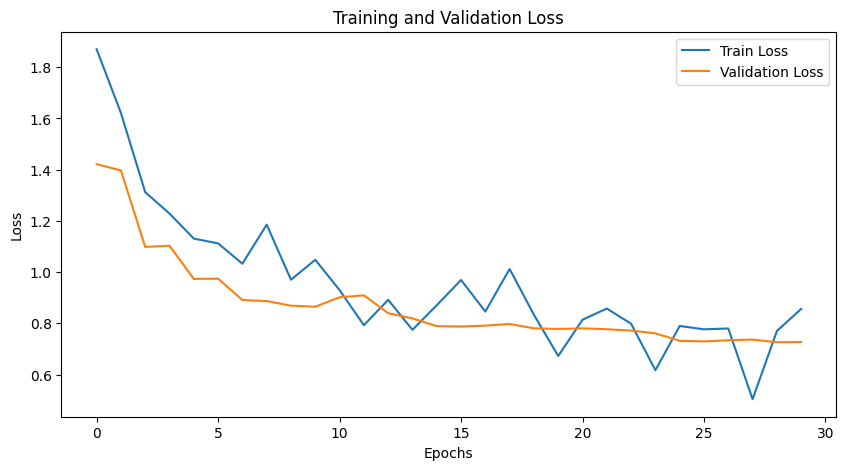

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Both training and validation loss decrease over epochs, with validation loss slightly lower than some training loss values in later epochs, suggesting effective regularization and minimal overfitting.

## Training and Validation Accuracy

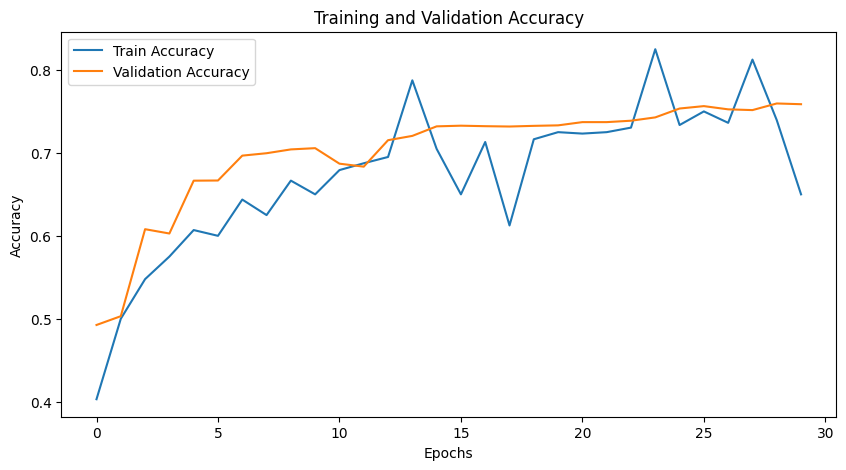

In [20]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Both training and validation accuracy improve over time; convergence is smooth, with validation closely following training, suggesting minimal overfitting.

## Model Evaluation

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=128, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test loss    : {test_loss:.2f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7600 - loss: 0.7212
Test Accuracy: 75.96%
Test loss    : 0.73


## Model Optimization for improved accuracy

In [32]:
# Parameters
num_classes = 10
weight_decay = 1e-4
batch_size = 128
epochs = 50

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)



# Callbacks
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True)

lr_scheduler = LearningRateScheduler(lr_schedule)



In [37]:
# Model
model2 = Sequential([
    Conv2D(32, (3,3), padding='same', activation='elu',
           kernel_regularizer=regularizers.l2(weight_decay), input_shape=x_train.shape[1:]),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='elu', kernel_regularizer=regularizers.l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(64, (3,3), padding='same', activation='elu', kernel_regularizer=regularizers.l2(weight_decay)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='elu', kernel_regularizer=regularizers.l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(128, (3,3), padding='same', activation='elu', kernel_regularizer=regularizers.l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.4),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

# Optimizer
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.001)

model2.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# Learning rate schedule
def lr_schedule(epoch):
    if epoch < 20:
        return 0.001
    elif epoch < 40:
        return 0.0005
    else:
        return 0.0003



In [39]:
# Train
history2 = model2.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)



Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.3669 - loss: 1.7647 - val_accuracy: 0.5444 - val_loss: 1.2888 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.5435 - loss: 1.3009 - val_accuracy: 0.5607 - val_loss: 1.3136 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.5998 - loss: 1.1480 - val_accuracy: 0.5715 - val_loss: 1.3280 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.6361 - loss: 1.0589 - val_accuracy: 0.6300 - val_loss: 1.1516 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.6577 - loss: 1.0010 - val_accuracy: 0.6384 - val_loss: 1.1152 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.6827 - loss: 0.9385 - val_accuracy: 0.6874 - val_loss: 0.9288 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.6999 - loss: 0.8917

## Plot Training and Validation Loss

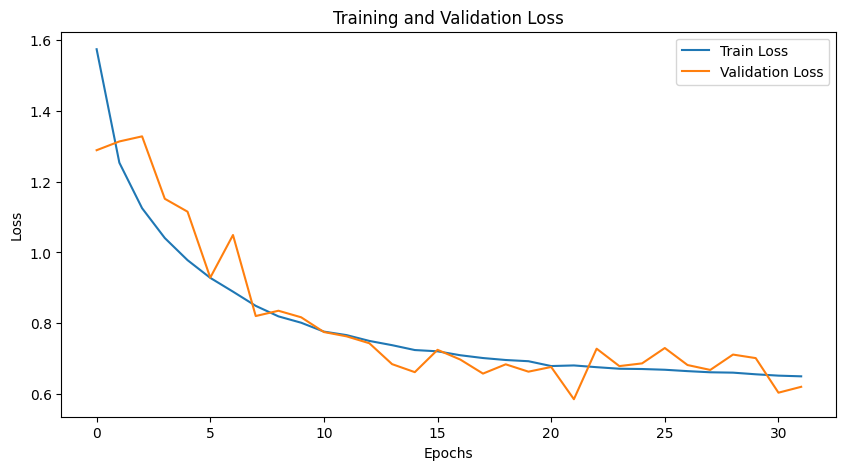

In [40]:
plt.figure(figsize=(10,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Both training and validation losses decrease overall, with validation loss closely following training loss, suggesting effective regularization and minimal overfitting.

## Training and Validation Accuracy

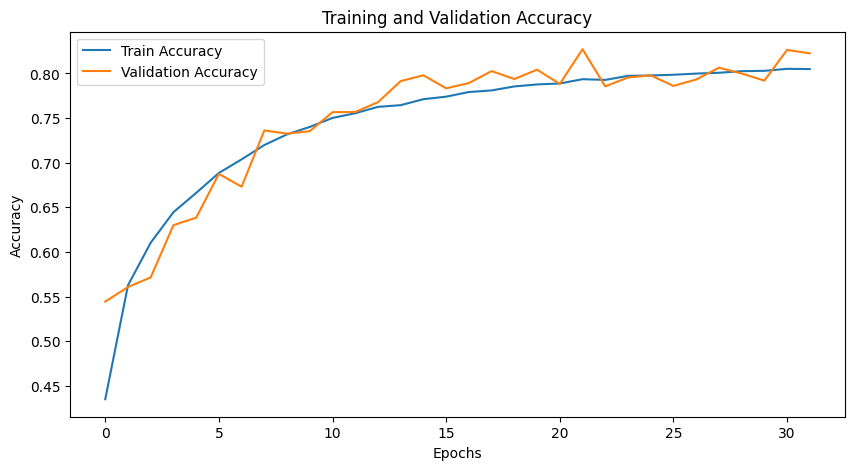

In [41]:
plt.figure(figsize=(10,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Both curves steadily improve, with validation accuracy tracking training accuracy closely, confirming the model’s stability and optimization.

## Model Evaluation

In [42]:
test_loss, test_acc = model2.evaluate(x_test, y_test, batch_size=batch_size)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test loss    : {test_loss:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8270 - loss: 0.5862
Test Accuracy: 82.71%
Test loss    : 0.5854


The optimized model achieved a test accuracy of 82.71% with a test loss of 0.585, demonstrating improved generalization and performance compared to the initial model.

## Prediction

In [53]:
from matplotlib.pyplot import imshow
labels = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

def show_preds(X, model):
    preds = np.argmax(model.predict(X[:16]), axis=1)
    plt.figure(figsize=(5,5))

    for k in range(16):
      plt.subplot(4, 4, k+1)
      plt.imshow(X[k])
      plt.axis('off')
      plt.title(labels[preds[k]], fontsize=9)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


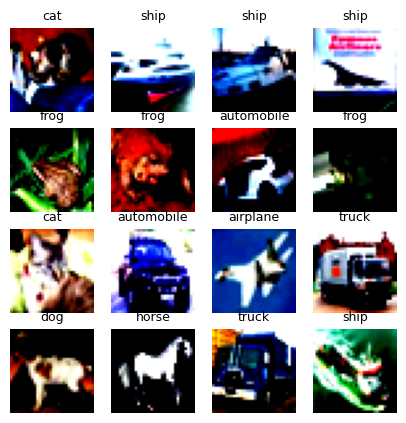

In [54]:
show_preds(x_test[:16],model2)

## Final Observations:

Model Performance:

- The initial CNN achieved 75.96% test accuracy with a test loss of 0.73.

- After optimization, the model reached 82.71% test accuracy with a test loss of 0.585, showing clear improvement.

Training Dynamics:

- Both models showed steady decrease in training and validation losses, and gradual increase in accuracies, indicating stable convergence.

- Validation metrics closely tracked training metrics, suggesting minimal overfitting and good generalization.

Optimized Model Effectiveness:

- Regularization, dropout, batch normalization, and learning rate scheduling improved performance.

- alidation accuracy peaked around 82%, aligning with high test accuracy.

Prediction on New Data:

- The optimized model can effectively classify unseen images, with expected generalization comparable to test performance.

## Conclusion:
- The optimized CNN model provides a reliable and well-generalized solution for CIFAR-10 classification, with clear improvements over the baseline model.